Series matching SO2: 75 / 1334


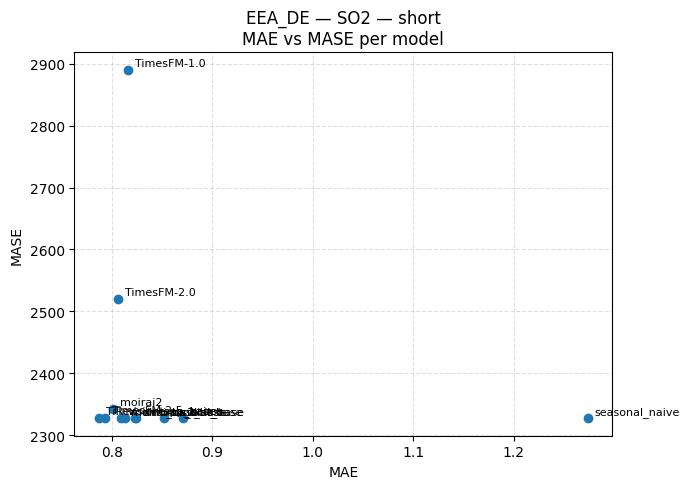

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path("output/results")
DATA_DIR    = Path("data2/hf_dataset")
DATASET     = "EEA_DE"
FREQ        = "H"
HORIZON     = "short"
POLLUTANT   = "SO2"   # filter item_ids by pollutant suffix
# ─────────────────────────────────────────────────────────────────────────────

# Load series index from HF dataset to get pollutant mask
ds = load_from_disk(str(DATA_DIR / DATASET / FREQ))
item_ids = ds["item_id"]                             # list[str]
mask = np.array([iid.endswith(f"_{POLLUTANT}") for iid in item_ids])
print(f"Series matching {POLLUTANT}: {mask.sum()} / {len(mask)}")

# Collect per-model mean MAE and MASE (averaged over matching series and windows)
records = []
for model_dir in sorted(RESULTS_DIR.iterdir()):
    npz_path = model_dir / DATASET / FREQ / HORIZON / "metrics.npz"
    if not npz_path.exists():
        continue
    m = np.load(npz_path)
    # shape: (n_series, n_windows, 1)  — squeeze last dim, then take nanmean
    mae  = np.nanmean(m["MAE"] [..., 0][mask])
    mase = np.nanmean(m["MASE"][..., 0][mask])
    records.append({"model": model_dir.name, "MAE": mae, "MASE": mase})

models = [r["model"] for r in records]
maes   = [r["MAE"]   for r in records]
mases  = [r["MASE"]  for r in records]

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(maes, mases, zorder=3)
for model, x, y in zip(models, maes, mases):
    ax.annotate(model, (x, y), textcoords="offset points", xytext=(5, 3), fontsize=8)

ax.set_xlabel("MAE")
ax.set_ylabel("MASE")
ax.set_title(f"{DATASET} — {POLLUTANT} — {HORIZON}\nMAE vs MASE per model")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


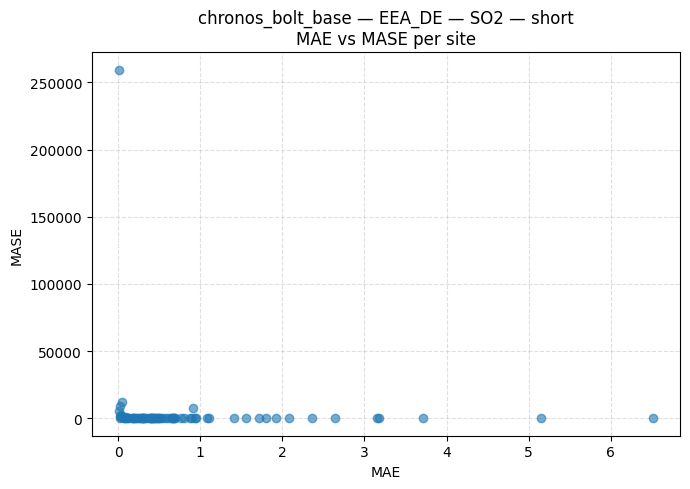

In [4]:
# ── Per-site scatter for one model ───────────────────────────────────────────
MODEL = "chronos_bolt_base"   # <-- change to any model in RESULTS_DIR

npz_path = RESULTS_DIR / MODEL / DATASET / FREQ / HORIZON / "metrics.npz"
m = np.load(npz_path)

# shape: (n_series, n_windows, 1) → mean over windows for matching series
mae_per_site  = np.nanmean(m["MAE"] [..., 0], axis=1)[mask]
mase_per_site = np.nanmean(m["MASE"][..., 0], axis=1)[mask]
site_labels   = [iid for iid, keep in zip(item_ids, mask) if keep]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mae_per_site, mase_per_site, alpha=0.6, zorder=3)
ax.set_xlabel("MAE")
ax.set_ylabel("MASE")
ax.set_title(f"{MODEL} — {DATASET} — {POLLUTANT} — {HORIZON}\nMAE vs MASE per site")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
